# Задание 6. Сравнение алгоритмов регрессии (метод опорных векторов и дерево решений) на наборе данных Boston Housing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # <--- Вот это пропущенный импорт, из-за которого была ошибка
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 8)

# --- ЗАГРУЗКА ДАННЫХ (ИСПРАВЛЕННАЯ) ---
# Стандартная функция load_boston удалена из sklearn из-за этических проблем.
# Загружаем данные напрямую из оригинального источника:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Имена признаков (стандартные для Boston Housing)
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Создаем DataFrame для удобства (как это делал бы load_boston)
boston_df = pd.DataFrame(data, columns=feature_names)
boston_df['MEDV'] = target

print("Данные успешно загружены!")
print("Размер датасета:", boston_df.shape)
boston_df.head()

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\david\AppData\Local\Temp\ipykernel_27432\1059425408.py:22: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


URLError: <urlopen error [Errno 11001] getaddrinfo failed>

## Пункт 1

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(boston_df.drop(['medv'], axis=1), boston_df['medv'])

KeyError: "['medv'] not found in axis"

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

NameError: name 'StandardScaler' is not defined

## Пункт 2

In [ ]:
from sklearn.svm import SVR

In [ ]:
svr = SVR(kernel='linear')

In [ ]:
svr.fit(X_train, y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [ ]:
y_pred = svr.predict(X_test)

## Пункт 3

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")

R² Score: 0.715
MSE: 24.748
RMSE: 4.975
MAE: 3.279


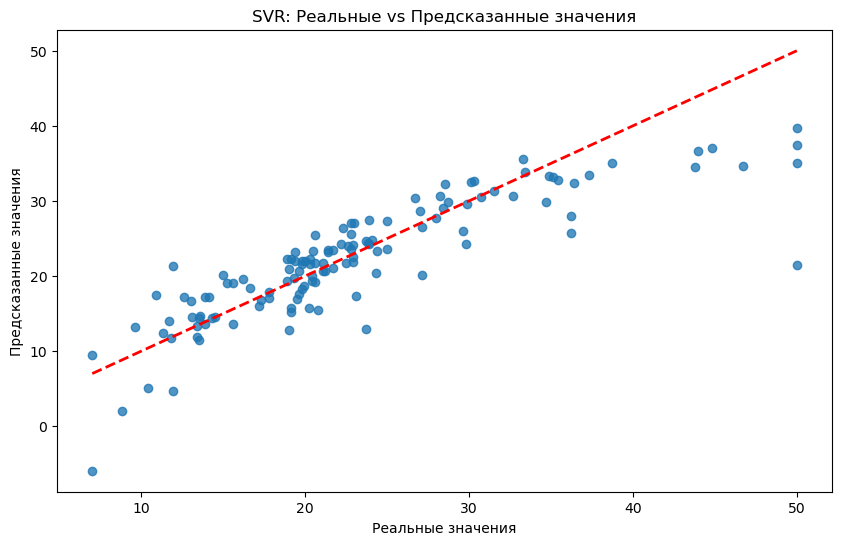

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.78)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('SVR: Реальные vs Предсказанные значения')
plt.show()

## Пункт 4

In [ ]:
from sklearn.model_selection import GridSearchCV

svr_params = {'C' : [0.1, 1, 10, 100],
             'gamma' : ['scale', 'auto', 0.1, 0.001, 10, 1],
            'kernel': ['rbf', 'linear']}

grid_search = GridSearchCV(SVR(), param_grid=svr_params, cv=5)
grid_search.fit(X_train, y_train)

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [ ]:
print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
print("Лучший результат", grid_search.best_score_)

Лучший результат 0.8747038051829128


## Задача 6.2. Дерево решений для регрессии

In [ ]:
from sklearn import datasets

california_df = datasets.fetch_california_housing()

In [ ]:
california_df.target_names

['MedHouseVal']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(california_df.data, california_df.target,
                                                   train_size=0.7)

In [ ]:
X_train.shape, y_train.shape

((14447, 8), (14447,))

In [ ]:
from sklearn.tree import DecisionTreeRegressor

DCR = DecisionTreeRegressor(min_samples_leaf=0.05)
DCR.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,0.05
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
y_pred = DCR.predict(X_test)

In [ ]:
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")

R² Score: 0.575
MSE: 0.569
RMSE: 0.755
MAE: 0.554


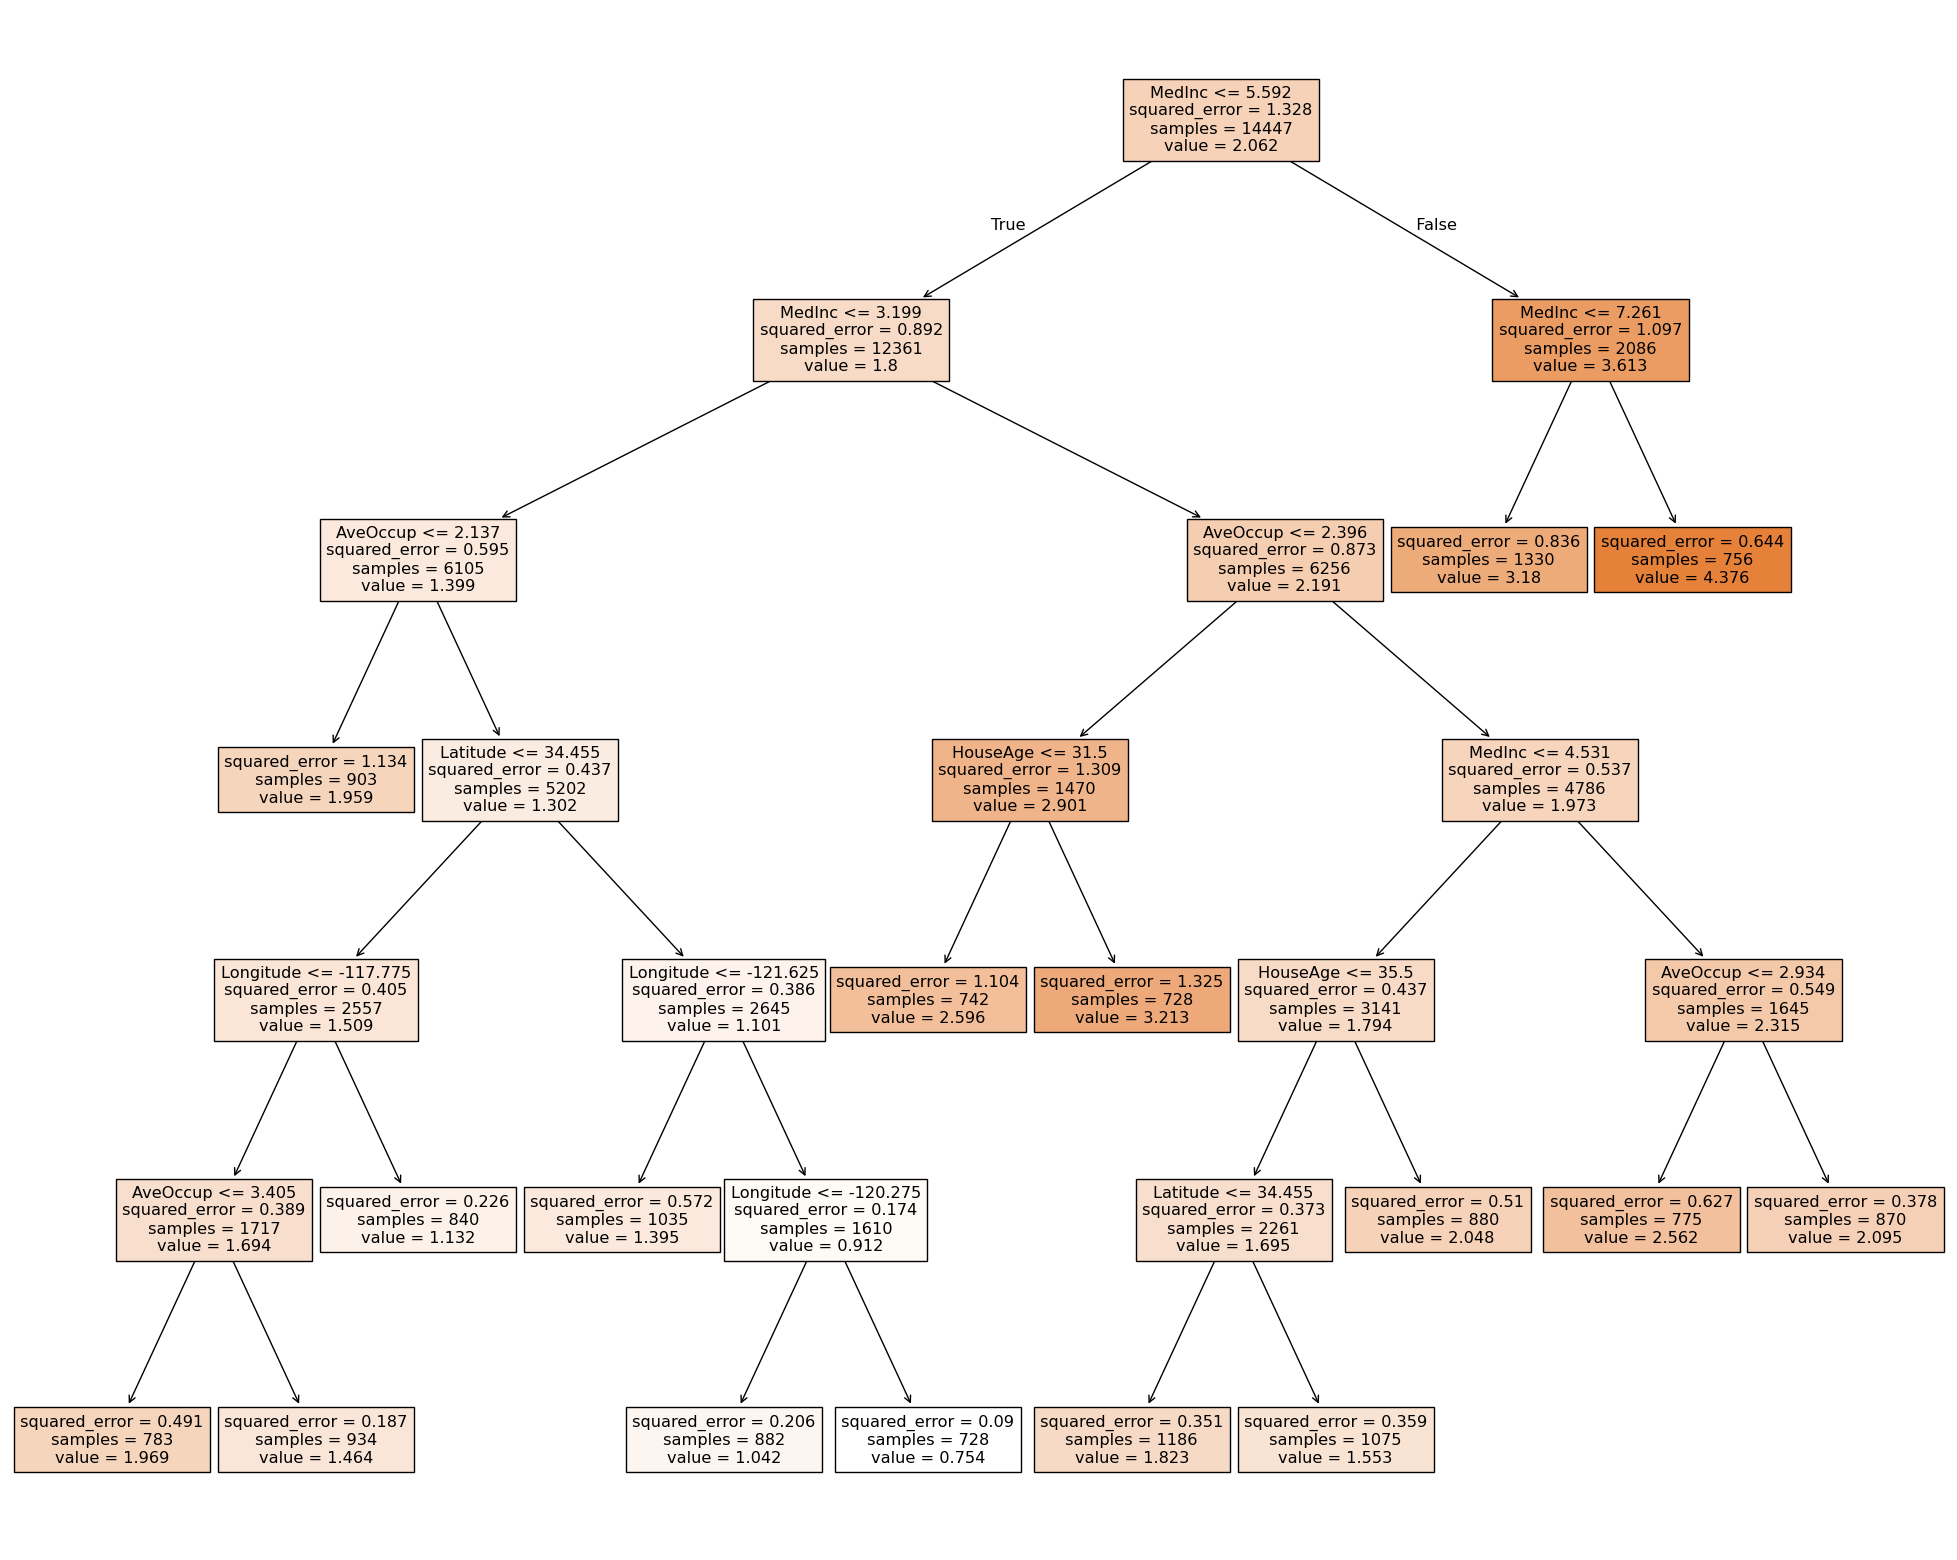

In [ ]:
from sklearn.tree import plot_tree

fig = plt.figure(figsize=(25,20))
_ = plot_tree(DCR,
                   feature_names=california_df.feature_names,
                   class_names=california_df.target_names,
                   filled=True)

In [ ]:
params_grid = {'min_samples_leaf': [0.02, 0.05, 0.1, 0.2, 0.3], 'min_samples_split': [0.02, 0.05, 0.1, 0.2, 0.3]}
grid_search = GridSearchCV(DecisionTreeRegressor(), params_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'min_samples_leaf': [0.02, 0.05, ...], 'min_samples_split': [0.02, 0.05, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [ ]:
print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'min_samples_leaf': 0.02, 'min_samples_split': 0.02}


## Задача 6.3. Сравнительный анализ методов SVM и дерева решений в задачах регрессии

In [ ]:
diabet_df = datasets.load_diabetes()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(diabet_df.data, diabet_df.target)

In [ ]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

In [ ]:
svr_linear = SVR(kernel='linear')
svr_rbf = SVR(kernel='rbf')

In [ ]:
tree_7 = DecisionTreeRegressor(max_depth=7)
tree_4 = DecisionTreeRegressor(max_depth=4)

In [ ]:
svr_linear.fit(X_train, y_train)
svr_rbf.fit(X_train, y_train)
tree_7.fit(X_train, y_train)
tree_4.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
import time
import numpy as np

def compare_models(models, model_names, X_train, y_train, X_test, y_test):
    """
    Комплексное сравнение моделей
    """
    results = {}
    training_times = {}
    prediction_times = {}
    
    print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
    print("=" * 50)
    
    for i, (model, name) in enumerate(zip(models, model_names)):
        print(f"\n--- {name} ---")
        
        # Измерение времени обучения
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        training_times[name] = training_time
        
        # Измерение времени предсказания
        start_time = time.time()
        y_pred = model.predict(X_test)
        prediction_time = time.time() - start_time
        prediction_times[name] = prediction_time
        
        # Метрики качества
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'Training Time': training_time,
            'Prediction Time': prediction_time
        }
        
        print(f"MSE: {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"Время обучения: {training_time:.4f} сек")
        print(f"Время предсказания: {prediction_time:.4f} сек")
    
    return results, training_times, prediction_times

# Список моделей и их имен
models = [svr_linear, svr_rbf, tree_7, tree_4]
model_names = ['SVR Linear', 'SVR RBF', 'Decision Tree (depth=7)', 'Decision Tree (depth=4)']

# Запуск сравнения
results, training_times, prediction_times = compare_models(
    models, model_names, X_train, y_train, X_test, y_test
)

=== СРАВНЕНИЕ МОДЕЛЕЙ ===

--- SVR Linear ---
MSE: 3096.3221
RMSE: 55.6446
MAE: 45.0271
R²: 0.4031
Время обучения: 0.0109 сек
Время предсказания: 0.0021 сек

--- SVR RBF ---
MSE: 4151.1604
RMSE: 64.4295
MAE: 54.1525
R²: 0.1997
Время обучения: 0.0102 сек
Время предсказания: 0.0063 сек

--- Decision Tree (depth=7) ---
MSE: 6102.7090
RMSE: 78.1198
MAE: 62.1856
R²: -0.1765
Время обучения: 0.0025 сек
Время предсказания: 0.0002 сек

--- Decision Tree (depth=4) ---
MSE: 4649.0124
RMSE: 68.1837
MAE: 54.3223
R²: 0.1037
Время обучения: 0.0027 сек
Время предсказания: 0.0008 сек


In [ ]:
def analyze_outlier_robustness(models, model_names, X_train, y_train, X_test, y_test):
    """
    Анализ устойчивости к выбросам
    """
    # Добавляем выбросы в тестовые данные
    np.random.seed(42)
    X_test_with_outliers = X_test.copy()
    y_test_with_outliers = y_test.copy()
    
    # Добавляем 10% выбросов
    n_outliers = int(0.1 * len(X_test))
    outlier_indices = np.random.choice(len(X_test), n_outliers, replace=False)
    
    # Создаем выбросы (увеличиваем значения в 3 раза)
    X_test_with_outliers[outlier_indices] *= 3
    y_test_with_outliers[outlier_indices] *= 3
    
    print("\n=== АНАЛИЗ УСТОЙЧИВОСТИ К ВЫБРОСАМ ===")
    print("=" * 60)
    
    robustness_results = {}
    
    for model, name in zip(models, model_names):
        # Предсказания на исходных данных
        y_pred_clean = model.predict(X_test)
        mse_clean = mean_squared_error(y_test, y_pred_clean)
        
        # Предсказания на данных с выбросами
        y_pred_outliers = model.predict(X_test_with_outliers)
        mse_with_outliers = mean_squared_error(y_test_with_outliers, y_pred_outliers)
        
        # Изменение MSE
        mse_change = ((mse_with_outliers - mse_clean) / mse_clean) * 100
        
        robustness_results[name] = {
            'MSE_clean': mse_clean,
            'MSE_with_outliers': mse_with_outliers,
            'MSE_change_percent': mse_change
        }
        
        print(f"\n{name}:")
        print(f"  MSE на чистых данных: {mse_clean:.4f}")
        print(f"  MSE на данных с выбросами: {mse_with_outliers:.4f}")
        print(f"  Изменение MSE: {mse_change:+.2f}%")
        
        if abs(mse_change) < 20:
            robustness = "Высокая"
        elif abs(mse_change) < 50:
            robustness = "Средняя"
        else:
            robustness = "Низкая"
            
        print(f"  Устойчивость к выбросам: {robustness}")
    
    return robustness_results

# Анализ устойчивости к выбросам
robustness_results = analyze_outlier_robustness(
    models, model_names, X_train, y_train, X_test, y_test
)


=== АНАЛИЗ УСТОЙЧИВОСТИ К ВЫБРОСАМ ===

SVR Linear:
  MSE на чистых данных: 3096.3221
  MSE на данных с выбросами: 13587.8837
  Изменение MSE: +338.84%
  Устойчивость к выбросам: Низкая

SVR RBF:
  MSE на чистых данных: 4151.1604
  MSE на данных с выбросами: 14859.0281
  Изменение MSE: +257.95%
  Устойчивость к выбросам: Низкая

Decision Tree (depth=7):
  MSE на чистых данных: 6102.7090
  MSE на данных с выбросами: 13898.0106
  Изменение MSE: +127.74%
  Устойчивость к выбросам: Низкая

Decision Tree (depth=4):
  MSE на чистых данных: 4649.0124
  MSE на данных с выбросами: 12617.0935
  Изменение MSE: +171.39%
  Устойчивость к выбросам: Низкая


In [ ]:
DCT_params_7 = {
            # 'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
    'max_depth': [7]
        }

DCT_params_4 = {
            # 'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
    'max_depth': [4]
        }

In [ ]:
SVR_params_linear = {
                'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['linear']
}

SVR_params_rbf = {
                'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

In [ ]:
grid_search_svr_linear = GridSearchCV(SVR(), param_grid=SVR_params_linear, cv=5)
grid_search_svr_rbf = GridSearchCV(SVR(), param_grid=SVR_params_rbf, cv=5)
grid_search_svr_linear.fit(X_train, y_train)
grid_search_svr_rbf.fit(X_train, y_train)

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [ ]:
grid_search_dcr_7 = GridSearchCV(DecisionTreeRegressor(), param_grid=DCT_params_7, cv=5)
grid_search_dcr_4 = GridSearchCV(DecisionTreeRegressor(), param_grid=DCT_params_4, cv=5)
grid_search_dcr_4.fit(X_train, y_train)
grid_search_dcr_7.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [7], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [ ]:
print("Лучшие параметры для SVR_linear:", grid_search_svr_linear.best_params_, grid_search_svr_linear.best_score_)

Лучшие параметры для SVR_linear: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} 0.49629667172116304


In [ ]:
print("Лучшие параметры для SVR_rbf:", grid_search_svr_rbf.best_params_, grid_search_svr_rbf.best_score_)

Лучшие параметры для SVR_rbf: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'} 0.5134151907941994


In [ ]:
print("Лучшие параметры для DCR_4:", grid_search_dcr_4.best_params_, grid_search_dcr_4.best_score_)

Лучшие параметры для DCR_4: {'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 10} 0.36570969798159714


In [ ]:
print("Лучшие параметры для DCR_7:", grid_search_dcr_7.best_params_, grid_search_dcr_7.best_score_)

Лучшие параметры для DCR_7: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10} 0.2153369671723369


Какая модель показала лучшее качество на тестовой выборке?
> svr-linear

Как время обучения сравнивается у двух методов?
> time() - start_time

Какая модель более устойчива к выбросам в данных?
> Decision_tree(4)

В чем основные различия в интерпретации результатов двух методов?
> оба метода интерпретируемы

При каких условиях один метод может быть предпочтительнее другого?
> В зависимости от объема и распределения данных надо выбирать один из методов